# DSE/QF4212 Project

Installing requirements and Importing required files

In [ ]:
# Requirements
# %pip install pandas numpy matplotlib fredapi python-dotenv scipy scikit-learn joblib tdqm xgboost seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from fredapi import Fred

import os
from dotenv import load_dotenv
from scipy.optimize import minimize
from scipy import stats
from scipy.stats import spearmanr

from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import pickle
import glob
from pathlib import Path
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


from sklearn.metrics import r2_score

from joblib import Parallel, delayed
from tqdm.auto import tqdm

from itertools import product
from multiprocessing import Process

# from src import * Importing our own modules

API_KEY='084a38e9d6fd82146cf89b8c30eba224'
random.seed(4212)

## Preparing Data for next Step

In [ ]:
df = pd.read_csv('all_stocks_5yr.csv', index_col=0, parse_dates=True)

close = df.pivot_table(index='date', columns='Name', values='close').dropna(axis=1)
op = df.pivot_table(index='date', columns='Name', values='open')[[col for col in close.columns]]
high = df.pivot_table(index='date', columns='Name', values='high')[[col for col in close.columns]]
low = df.pivot_table(index='date', columns='Name', values='low')[[col for col in close.columns]]
volume = df.pivot_table(index='date', columns='Name', values='volume')[[col for col in close.columns]]

op.fillna(method='ffill', inplace=True)
high.fillna(method='ffill', inplace=True)
low.fillna(method='ffill', inplace=True)
volume.replace(0, np.nan, inplace=True)
volume.fillna(method='ffill', inplace=True)

returns = np.log(close).diff().dropna()

fred = Fred(api_key = API_KEY)
risk_free_rate = fred.get_series_latest_release('DGS3MO')/100/252
risk_free_rate = risk_free_rate.reindex(returns.index, method='ffill')
risk_free_rate.fillna(method='ffill', inplace=True)


with open('processed_data.pkl', 'wb') as f:
    pickle.dump((op, high, low, close, volume, returns, risk_free_rate), f)

## Feature Engineering

In [ ]:
class FeatureEngineer:
    """
    Compute time-series and cross-sectional features from OHLC data
    """
    
    def __init__(self, 
                 open: pd.DataFrame,
                 high: pd.DataFrame,
                 low: pd.DataFrame,
                 close: pd.DataFrame,
                 volume: pd.DataFrame,
                 returns: pd.DataFrame,
                 risk_free_rate,
                 lookback_days: int = 60):
        """
        Args:
            ohlc_df: Long format DataFrame with columns: 
                     ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']
            rf_rate: Series with date index and annualized 3-month T-bill rate (%)
            lookback_days: Minimum days of history needed for features
        """
        print("Initializing Feature Engineer...")

        self.close = close
        self.open = open
        self.high = high
        self.low = low
        self.volume = volume
        self.rf_rate = risk_free_rate 

        # Calculate returns
        self.returns = returns
        
        # Excess returns
        self.excess_returns = self.returns.sub(self.rf_rate, axis=0)
        
        self.lookback = lookback_days
        self.tickers = self.close.columns.tolist()
        self.dates = self.returns.index
        
        print(f"  Stocks: {len(self.tickers)}")
        print(f"  Date range: {self.dates[0].date()} to {self.dates[-1].date()}")
        print(f"  Lookback period: {lookback_days} days")

    def _compute_features_and_targets_generic(self,rebalance_dates, horizon_days: int, target: str, save_path: str = None) -> pd.DataFrame:
        """
        Generic method for any frequency/horizon combination
        
        Args:
            rebalance_dates: List of dates to compute features for
            horizon_days: Prediction horizon in days
            target: Target variable to compute ('return', 'volatility')
            save_path: Optional path to save features as pickle
        
        Returns:
            all_features: DataFrame with computed features
            targets_df: DataFrame with target variable
        """
        print("\nComputing features...")
        
        # Only compute for dates with sufficient history
        start_date = self.dates[self.lookback]
        valid_dates = [d for d in rebalance_dates if d >= start_date]
        
        all_features = {}
        targets_dict = {}

        print(f"  Total dates to compute: {len(valid_dates)}")
        
        for i, date in enumerate(valid_dates):
            if i % 50 == 0 or i == len(valid_dates) - 1:
                print(f"  Progress: {i+1}/{len(valid_dates)} ({(i+1)/len(valid_dates)*100:.1f}%)")
            
            # Get data up to (but not including) this date
            date_idx = self.dates.get_loc(date)
            window_start = date_idx - self.lookback
            window_end = date_idx
            
            # Extract windows
            returns_window = self.returns.iloc[window_start:window_end]
            excess_returns_window = self.excess_returns.iloc[window_start:window_end]
            close_window = self.close.iloc[window_start:window_end]
            volume_window = self.volume.iloc[window_start:window_end]
            high_window = self.high.iloc[window_start:window_end]
            low_window = self.low.iloc[window_start:window_end]

            # Compute features for this date
            date_features = self._compute_features_single_date(
                returns_window, 
                excess_returns_window,
                close_window,
                volume_window,
                high_window,
                low_window
            )         

            date_features = self.feature_subset_horizon(date_features, horizon_days, target)   

            date_features = date_features.set_index('ticker')
            all_features[date] = date_features
            if save_path:
                if not date_features.isna().values.any():
                    with open(save_path+str(date.date())+".pkl", 'wb') as f:
                        pickle.dump(date_features, f)  
                else:
                    print(date)   
        
            # Compute target
            if target == 'return':
                future_returns = self.returns.iloc[date_idx+1 : date_idx+1+horizon_days]
                targets = future_returns.sum(axis=0)  # Sum across days
            else:
                future_returns = self.returns.iloc[date_idx+1 : date_idx+1+horizon_days]
                rv = (future_returns ** 2).sum(axis=0)
                targets = rv * (252 / horizon_days)  # Annualise 
            targets_dict[date] = targets
        
        targets_dict = pd.DataFrame(targets_dict).T
        targets_dict.sort_index(inplace=True)

        if save_path:
            if not targets_dict.isna().values.any():
                with open(f"{save_path}{target}_{horizon_days}_targets.pkl", 'wb') as f:
                    pickle.dump(targets_dict, f)  
            else:
                print(date) 


        # Combine all dates
        features_df = pd.concat(all_features, ignore_index=True)
        
        print(f"\n✓ Feature computation complete!")
        print(f"  Shape: {features_df.shape}")
        print(f"  Features: {features_df.shape[1]}")
        print(f"  Memory: {features_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

        
        return features_df, targets_dict
    
    def compute_daily_return_features(self, save_path=None):
        dates = self.dates[self.lookback:]  # All dates
        return self._compute_features_and_targets_generic(
            dates, horizon_days=1, target='return', save_path=save_path
        )
    
    def compute_weekly_return_features(self, save_path=None):
        dates = self._get_weekly_dates()
        return self._compute_features_and_targets_generic(
            dates, horizon_days=5, target='return', save_path=save_path
        )
    
    def compute_monthly_return_features(self, save_path=None):
        dates = self._get_monthly_dates()
        return self._compute_features_and_targets_generic(
            dates, horizon_days=21, target='return', save_path=save_path
        )
    
    def compute_weekly_volatility_features(self, save_path=None):
        dates = self._get_weekly_dates()
        return self._compute_features_and_targets_generic(
            dates, horizon_days=5, target='volatility', save_path=save_path
        )
    
    def compute_monthly_volatility_features(self, save_path=None):
        dates = self._get_monthly_dates()
        return self._compute_features_and_targets_generic(
            dates, horizon_days=21, target='volatility', save_path=save_path
        )

    def _get_weekly_dates(self):
        """
        Get weekly rebalance dates (Mondays or first trading day of week)
        
        Returns:
            List of weekly dates
        """
        # Resample to weekly (Monday)
        weekly_dates = self.returns.groupby([self.returns.index.year, self.returns.index.isocalendar().week]).apply(lambda x: x.index[0]).tolist()
        # Ensure we have enough lookback history
        min_date = self.dates[self.lookback]
        weekly_dates = [d for d in weekly_dates if d >= min_date]
        
        return weekly_dates
    
    def _get_monthly_dates(self):
        """First trading day of each month"""
        monthly_dates = self.returns.groupby([self.returns.index.year, self.returns.index.month]).apply(lambda x: x.index[0]).tolist()
        min_date = self.dates[self.lookback]
        return [d for d in monthly_dates if d >= min_date]
    
    def _compute_features_single_date(self,
                                    returns_window: pd.DataFrame,
                                    excess_returns_window: pd.DataFrame,
                                    close_window: pd.DataFrame,
                                    volume_window: pd.DataFrame,
                                    high_window: pd.DataFrame,
                                    low_window: pd.DataFrame) -> pd.DataFrame:
        """
        Compute ALL features for one date across all stocks
        
        No for_return flag - computes complete feature set
        Feature selection happens in feature_subset_horizon()
        
        Returns:
            DataFrame with ~60-70 features per stock
        """
        n_stocks = len(self.tickers)
        features_list = []
        
        # === TIME-SERIES FEATURES (per stock) ===
        for i, ticker in enumerate(self.tickers):
            feat = {'ticker': ticker}

            # Do this to prevent future leakage, where we predict on day t using data from day t-1
            ret = returns_window.iloc[:, i].values
            excess_ret = excess_returns_window.iloc[:, i].values
            price = close_window.iloc[:, i].values
            vol = volume_window.iloc[:, i].values
            high = high_window.iloc[:, i].values
            low = low_window.iloc[:, i].values
            

            # MOMENTUM FEATURES

            # Short-term momentum
            feat['ret_1d'] = ret[-1] if len(ret) > 0 else 0
            feat['ret_5d'] = np.sum(ret[-5:]) if len(ret) >= 5 else 0
            
            # Medium-term momentum
            feat['ret_21d'] = np.sum(ret[-21:]) if len(ret) >= 21 else 0
            feat['excess_ret_21d'] = np.sum(excess_ret[-21:]) if len(excess_ret) >= 21 else 0
            
            # Long-term momentum
            feat['ret_63d'] = np.sum(ret[-63:]) if len(ret) >= 63 else 0
            feat['excess_ret_63d'] = np.sum(excess_ret[-63:]) if len(excess_ret) >= 63 else 0
            
            # VOLATILITY FEATURES
            
            # Standard deviation measures
            feat['vol_5d'] = np.std(ret[-5:]) if len(ret) >= 5 else 0
            feat['vol_21d'] = np.std(ret[-21:]) if len(ret) >= 21 else 0
            feat['vol_63d'] = np.std(ret[-63:]) if len(ret) >= 63 else 0
            
            # Realised variance (mean of squared returns)
            feat['rv_5d'] = np.mean(ret[-5:]**2) if len(ret) >= 5 else 0
            feat['rv_21d'] = np.mean(ret[-21:]**2) if len(ret) >= 21 else 0
            feat['rv_63d'] = np.mean(ret[-63:]**2) if len(ret) >= 63 else 0
            
            # EWMA volatility
            if len(ret) >= 21:
                lambda_decay = 0.94
                ewma_var = 0
                for j in range(len(ret)-1, max(len(ret)-22, 0), -1):
                    ewma_var = lambda_decay * ewma_var + (1 - lambda_decay) * ret[j]**2
                feat['vol_ewma'] = np.sqrt(ewma_var) if ewma_var > 0 else 0
            else:
                feat['vol_ewma'] = 0
            
            # Downside volatility (semi-deviation)
            if len(ret) >= 21:
                downside_returns = ret[-21:][ret[-21:] < 0]
                feat['downside_vol_21d'] = np.std(downside_returns) if len(downside_returns) > 0 else 0
            else:
                feat['downside_vol_21d'] = 0
            
            # ==========================================
            # VOLATILITY DYNAMICS
            # ==========================================
            
            # Realised variance ratios
            feat['rv_ratio_5_21'] = feat['rv_5d'] / feat['rv_21d'] if feat['rv_21d'] > 0 else 0
            feat['rv_ratio_5_63'] = feat['rv_5d'] / feat['rv_63d'] if feat['rv_63d'] > 0 else 0
            feat['rv_ratio_21_63'] = feat['rv_21d'] / feat['rv_63d'] if feat['rv_63d'] > 0 else 0
            
            # Realised variance trend
            feat['rv_trend'] = (feat['rv_21d'] - feat['rv_63d']) / feat['rv_63d'] if feat['rv_63d'] > 0 else 0
            
            # ==========================================
            # TECHNICAL INDICATORS
            # ==========================================
            
            # Moving average ratios
            if len(price) >= 21:
                ma20 = np.mean(price[-21:])
                feat['price_ma20'] = (price[-1] / ma20) - 1
            else:
                feat['price_ma20'] = 0
            
            if len(price) >= 50:
                ma50 = np.mean(price[-50:])
                feat['price_ma50'] = (price[-1] / ma50) - 1
            else:
                feat['price_ma50'] = 0
            
            # Momentum acceleration
            if len(ret) >= 21:
                recent = np.sum(ret[-5:])
                older = np.sum(ret[-21:-5]) / 16 * 5  # Normalise to same period
                feat['momentum_accel'] = recent - older
            else:
                feat['momentum_accel'] = 0
            
            # High-low range position
            if len(high) >= 21:
                high_21 = np.max(high[-21:])
                low_21 = np.min(low[-21:])
                if high_21 != low_21:
                    feat['range_position'] = (price[-1] - low_21) / (high_21 - low_21)
                else:
                    feat['range_position'] = 0.5
            else:
                feat['range_position'] = 0.5
            
            # RSI (14-period)
            if len(price) >= 15:
                deltas = np.diff(price[-15:])
                ups = deltas[deltas > 0].sum() / 14
                downs = -deltas[deltas < 0].sum() / 14
                rs = ups / downs if downs > 0 else 0
                feat['rsi_14'] = 100 - (100 / (1 + rs))
            else:
                feat['rsi_14'] = 50
            
            # Drawdown from peak
            if len(price) >= 21:
                peak = np.max(price[-21:])
                feat['drawdown_21d'] = (price[-1] / peak) - 1
            else:
                feat['drawdown_21d'] = 0
            
            # ==========================================
            # LAGGED RETURNS (for daily predictions)
            # ==========================================
            
            for lag in range(1, 21):
                feat[f'ret_lag_{lag}d'] = ret[-lag] if len(ret) >= lag else 0

            # LAGGED RETURNS (for weekly predictions)
            for lag in range(1, 5):
                feat[f'ret_lag_{(lag-1)*5+1}-{lag*5+1}w'] = ret[-lag * 5-1:-(lag-1)*5-1].sum() if len(ret) >= lag * 5 else 0

            # LAGGED RETURNS (for monthly predictions)
            for lag in range(1, 3):
                feat[f'ret_lag_{(lag-1)*21+1}-{lag*21+1}w'] = ret[-lag * 21-1:-(lag-1)*21-1].sum() if len(ret) >= lag * 21 else 0

            # ==========================================
            # VOLUME FEATURES
            # ==========================================
            
            # Volume ratio
            if len(vol) >= 21:
                avg_vol = np.mean(vol[-21:])
                current_vol = vol[-1]
                feat['volume_ratio'] = current_vol / avg_vol if avg_vol > 0 else 1
            else:
                feat['volume_ratio'] = 1
            
            # Volume volatility
            if len(vol) >= 21:
                feat['volume_vol_21d'] = np.std(vol[-21:]) / (np.mean(vol[-21:]) + 1e-8)
            else:
                feat['volume_vol_21d'] = 0
            
            # ==========================================
            # LIQUIDITY FEATURES
            # ==========================================
            
            if len(ret) >= 21 and len(vol) >= 21:
                # Amihud illiquidity measure
                abs_returns_sum = np.abs(ret[-21:]).sum()
                volume_sum = vol[-21:].sum()
                feat['illiquidity_21d'] = abs_returns_sum / (volume_sum + 1e-8)
                
                # High-low spread proxy
                hl_spreads = (high[-21:] - low[-21:]) / (close_window.iloc[:, i].values[-21:] + 1e-8)
                feat['hl_spread_21d'] = np.mean(hl_spreads)
            else:
                feat['illiquidity_21d'] = 0
                feat['hl_spread_21d'] = 0
            
            # ==========================================
            # RISK FEATURES
            # ==========================================
            
            # Sharpe-like ratio
            if len(excess_ret) >= 21 and feat['vol_21d'] > 0:
                feat['sharpe_21d'] = feat['excess_ret_21d'] / (feat['vol_21d'] * np.sqrt(21))
            else:
                feat['sharpe_21d'] = 0
            
            # Skewness and kurtosis
            if len(ret) >= 21:
                feat['skew_21d'] = stats.skew(ret[-21:])
                feat['kurt_21d'] = stats.kurtosis(ret[-21:])
            else:
                feat['skew_21d'] = 0
                feat['kurt_21d'] = 0
            
            # ==========================================
            # TAIL/JUMP FEATURES
            # ==========================================
            
            # Maximum absolute return
            if len(ret) >= 21:
                feat['max_ret_21d'] = np.max(np.abs(ret[-21:]))
                feat['min_ret_21d'] = np.min(ret[-21:])
            else:
                feat['max_ret_21d'] = 0
                feat['min_ret_21d'] = 0
            
            # Tail ratio (95th percentile / 5th percentile)
            if len(ret) >= 63:
                p95 = np.percentile(ret[-63:], 95)
                p5 = np.percentile(ret[-63:], 5)
                feat['tail_ratio'] = p95 / abs(p5) if p5 != 0 else 1
            else:
                feat['tail_ratio'] = 1
            
            features_list.append(feat)
        
        # Convert to DataFrame
        df = pd.DataFrame(features_list)
        
        # ==========================================
        # CROSS-SECTIONAL FEATURES
        # ==========================================
        
        # Market (equal-weighted)
        market_ret = returns_window.mean(axis=1)
        
        # Percentile ranks for momentum
        for col in ['ret_21d', 'ret_63d', 'excess_ret_21d']:
            if col in df.columns:
                df[f'{col}_pct'] = df[col].rank(pct=True)

        # Percentile ranks for higher order lags
        for col in [f'ret_lag_{(lag-1)*5+1}-{lag*5+1}w' for lag in range(1, 5)]:
            if col in df.columns:
                df[f'{col}_pct'] = df[col].rank(pct=True)


        for col in [f'ret_lag_{(lag-1)*21+1}-{lag*21+1}w' for lag in range(1, 3)]:
            if col in df.columns:
                df[f'{col}_pct'] = df[col].rank(pct=True)
        
        # Percentile ranks for volatility
        for col in ['vol_21d', 'vol_5d', 'vol_63d']:
            if col in df.columns:
                df[f'{col}_pct'] = df[col].rank(pct=True)
        
        # Z-scores
        for col in ['ret_21d', 'vol_21d']:
            if col in df.columns:
                mean = df[col].mean()
                std = df[col].std()
                if std > 0:
                    df[f'{col}_zscore'] = (df[col] - mean) / std
                else:
                    df[f'{col}_zscore'] = 0
        
        # Beta to market
        betas = []
        for i in range(n_stocks):
            stock_ret = returns_window.iloc[:, i].values
            if len(stock_ret) >= 60 and len(market_ret) >= 60:
                cov = np.cov(stock_ret[-60:], market_ret[-60:].values)[0, 1]
                var = np.var(market_ret[-60:].values)
                beta = cov / var if var > 0 else 1
            else:
                beta = 1
            betas.append(beta)
        
        df['beta'] = betas
        df['beta_pct'] = pd.Series(betas).rank(pct=True).values
        
        # Correlation to market
        correlations = []
        for i in range(n_stocks):
            stock_ret = returns_window.iloc[:, i].values
            if len(stock_ret) >= 60 and len(market_ret) >= 60:
                corr = np.corrcoef(stock_ret[-60:], market_ret[-60:].values)[0, 1]
            else:
                corr = 0
            correlations.append(corr)
        
        df['corr_market'] = correlations
        
        # Risk-adjusted momentum
        df['risk_adj_mom'] = df['excess_ret_21d'] / (df['vol_21d'] + 1e-8)
        df['risk_adj_mom_pct'] = df['risk_adj_mom'].rank(pct=True)
        
        # Momentum-volatility interaction
        df['mom_vol_interaction'] = df['ret_21d'] * df['vol_21d']
        
        return df


    def feature_subset_horizon(self, features: pd.DataFrame, horizon_days: int, target: str) -> pd.DataFrame:
        """
        Select feature subsets based on prediction horizon and target type
        
        Uses predefined feature pools for consistency and maintainability
        
        Args:
            features: DataFrame with all features
            horizon_days: Prediction horizon in days (1, 5, or 21)
            target: Target variable ('return' or 'volatility')
        
        Returns:
            DataFrame with selected features
        """
        
        # ==========================================
        # FEATURE POOL DEFINITIONS
        # ==========================================
        
        pools = {
            # Momentum features (different horizons)
            'momentum_short': ['ret_1d', 'ret_5d'],
            'momentum_medium': ['ret_21d', 'excess_ret_21d'],
            'momentum_long': ['ret_63d', 'excess_ret_63d'],
            
            # Volatility measures
            'volatility_short': ['vol_5d', 'rv_5d'],
            'volatility_medium': ['vol_21d', 'rv_21d', 'vol_ewma', 'downside_vol_21d'],
            'volatility_long': ['vol_63d', 'rv_63d'],
            
            # Volatility dynamics
            'vol_dynamics': ['rv_ratio_5_21', 'rv_ratio_5_63', 'rv_ratio_21_63', 'rv_trend'],
            
            # Technical indicators
            'technical_short': [f'ret_lag_{i}d' for i in range(1, 6)],  # Lags 1-5
            'technical_medium': ['price_ma20', 'momentum_accel', 'range_position', 'rsi_14'],
            'technical_long': ['price_ma50', 'drawdown_21d'],

            # Higher order lags
            'higher_order_lags_medium': [f'ret_lag_{(i-1)*5+1}-{i*5+1}w' for i in range(1, 5)],  # Weekly lags
            'higher_order_lags_high': [f'ret_lag_{(i-1)*21+1}-{i*21+1}w' for i in range(1, 3)],  # Monthly lags

            # Volume features
            'volume': ['volume_ratio', 'volume_vol_21d'],
            
            # Risk features
            'risk': ['sharpe_21d', 'skew_21d', 'kurt_21d'],
            
            # Liquidity features
            'liquidity': ['illiquidity_21d', 'hl_spread_21d'],
            
            # Tail/jump features
            'tail': ['max_ret_21d', 'min_ret_21d', 'tail_ratio'],
            
            # Cross-sectional features
            'cross_sectional_day': [
                'ret_21d_pct', 'ret_63d_pct', 'excess_ret_21d_pct',
                'vol_21d_pct', 'vol_5d_pct', 'vol_63d_pct',
                'ret_21d_zscore', 'vol_21d_zscore',
                'beta', 'beta_pct', 'corr_market',
                'risk_adj_mom', 'risk_adj_mom_pct', 'mom_vol_interaction'
            ],

            'cross_sectional_week': [
                'vol_21d_pct', 'vol_5d_pct', 'vol_63d_pct',
                'vol_21d_zscore',
                'beta', 'beta_pct', 'corr_market',
                'risk_adj_mom', 'risk_adj_mom_pct', 'mom_vol_interaction'
            ] + [f'ret_lag_{(i-1)*5+1}-{i*5+1}w_pct' for i in range(1, 5)],

            'cross_sectional_month': [
                'vol_21d_pct', 'vol_63d_pct',
                'vol_21d_zscore',
                'beta', 'beta_pct', 'corr_market',
                'risk_adj_mom', 'risk_adj_mom_pct', 'mom_vol_interaction'
            ] + [f'ret_lag_{(i-1)*21+1}-{i*21+1}w_pct' for i in range(1, 3)],
        }
        
        # ==========================================
        # SELECTION RULES BY (TARGET, HORIZON)
        # ==========================================
        
        selection_rules = {
            # === RETURN PREDICTION ===
            
            ('return', 1): {  # Daily returns
                'pools': [
                    'momentum_short',      # Use very recent returns
                    'volatility_short',    # Recent volatility
                    'volatility_medium',   # For risk adjustment
                    'technical_short',     # Lagged returns 1-5d
                    'technical_medium',    # MA, RSI, momentum accel
                    'volume',              # Volume signals
                    'risk',                # Sharpe, skew, kurtosis
                    'liquidity',           # Illiquidity, spread
                    'cross_sectional_day'      # Rankings, beta
                ],
                'exclude': [],
                'rationale': 'Daily: Use all high-frequency signals and microstructure'
            },
            
            ('return', 5): {  # Weekly returns
                'pools': [
                    'volatility_medium',   # 21d vol for risk
                    'technical_medium',    # MA, range position
                    'technical_long',      # Longer MA, drawdown
                    'higher_order_lags_medium',  # Weekly lags
                    'volume',              # Volume signals
                    'risk',                # Risk metrics
                    'liquidity',           # Liquidity matters
                    'cross_sectional_week'      # Rankings
                ],
                'exclude': ['ret_1d', 'mom_vol_interaction', 'volume_ratio', 'beta'] + [f'ret_lag_{i}d' for i in range(1, 6)],  # Drop daily lags
                'rationale': 'Weekly: Drop daily noise, keep medium-term momentum'
            },
            
            ('return', 21): {  # Monthly returns
                'pools': [
                    'volatility_medium',   # 21d vol
                    'volatility_long',     # 63d vol
                    'technical_long',      # Long-term technical
                    'higher_order_lags_high',  # Monthly lags
                    'volume',              # Volume
                    'risk',                # Risk metrics
                    'cross_sectional_month'      # Rankings
                ],
                'exclude': ['vol_5d_pct', 'rv_5d'] +
                        [f'ret_lag_{i}d' for i in range(1, 21)],  # Drop all short-term
                'rationale': 'Monthly: Focus on persistent signals, drop short-term noise'
            },
            
            # === VOLATILITY PREDICTION ===
            
            ('volatility', 21): {  # Monthly volatility
                'pools': [
                    'volatility_medium',   # 21d vol
                    'volatility_long',     # 63d vol
                    'vol_dynamics',        # RV dynamics
                    'volume',              # Volume
                    'risk',                # Higher moments
                    'tail',                # Tail risk
                    'liquidity',           # Liquidity
                    'cross_sectional_month'      # Rankings
                ],
                'exclude': ['vol_5d', 'rv_5d', 'rv_ratio_5_21', 'rv_ratio_5_63'] + ['ret_21_d', 'excess_ret_21d', 'ret_63d', 'excess_ret_63d', 'ret_21d_zscore'],  # Drop short-term
                'rationale': 'Monthly vol: Focus on longer-term variance persistence'
            }
        }
        
        # ==========================================
        # FEATURE SELECTION LOGIC
        # ==========================================
        
        key = (target, horizon_days)
        if key not in selection_rules:
            raise ValueError(f"No selection rule for target={target}, horizon={horizon_days}. "
                            f"Valid combinations: {list(selection_rules.keys())}")
        
        rule = selection_rules[key]
        
        # Build feature list from pools
        selected_features = ['ticker']  # Always include ticker
        for pool_name in rule['pools']:
            if pool_name in pools:
                selected_features.extend(pools[pool_name])
        
        # Remove excluded features
        selected_features = [f for f in selected_features if f not in rule['exclude']]
        
        # Remove duplicates (maintain order)
        seen = set()
        selected_features = [f for f in selected_features if not (f in seen or seen.add(f))]
        
        # Filter to features that actually exist in DataFrame
        available_features = [f for f in selected_features if f in features.columns]
        
        # Warn about missing features
        missing = set(selected_features) - set(available_features) - {'ticker'}
        if missing:
            print(f"⚠ Warning: {len(missing)} expected features not found in data:")
            print(f"  Missing: {sorted(missing)[:10]}")  # Show first 10
        
        # Print summary
        print(f"\n✓ Selected {len(available_features)-1} features for {target} prediction (horizon={horizon_days}d)")
        print(f"  Pools used: {rule['pools']}")
        if rule['exclude']:
            print(f"  Excluded: {len(rule['exclude'])} features")
        
        return features[available_features]

In [ ]:
with open('src/processed_data.pkl', 'rb') as f:
    op, high, low, close, volume, returns, risk_free_rate = pickle.load(f)

# Create engineer
engineer = FeatureEngineer(op, high, low, close, volume, returns, risk_free_rate, lookback_days=70)

# Define functions
def func1():
    features, df = engineer.compute_monthly_volatility_features('src/data_monthly_var/')
    print(f"Monthly vol: {features.shape}, targets: {df.shape}")

def func3():
    features, df = engineer.compute_monthly_return_features('src/data_monthly_ret/')
    print(f"Monthly ret: {features.shape}, targets: {df.shape}")

def func4():
    features, df = engineer.compute_weekly_return_features('src/data_weekly_ret/')
    print(f"Weekly ret: {features.shape}, targets: {df.shape}")

def func5():
    features, df = engineer.compute_weekly_volatility_features('src/data_weekly_var/')
    print(f"Weekly vol: {features.shape}, targets: {df.shape}")

def func6():
    features, df = engineer.compute_daily_return_features('src/data_daily_ret/')
    print(f"Daily ret: {features.shape}, targets: {df.shape}")

if __name__ == '__main__':  # IMPORTANT: Protect entry point
    # Create processes
    p1 = Process(target=func1)
    p3 = Process(target=func3)
    p4 = Process(target=func4)
    p5 = Process(target=func5)
    p6 = Process(target=func6)
    
    # Start all
    p1.start()
    p3.start()
    p4.start()
    p5.start()
    p6.start()
    
    # Wait for completion
    p1.join()
    p3.join()
    p4.join()
    p5.join()
    p6.join()

    features, df = engineer.compute_daily_return_features('src/data_daily_vol/')
    
    print("✓ All feature engineering complete!")

For our test data we use 2017-02-08 to 2018-02-07

For our validation data we use 2014-03-03 to 2016-10-03

In [ ]:
with open('src/processed_data.pkl', 'rb') as f:
    op, high, low, close, volume, returns, risk_free_rate = pickle.load(f)

train_returns = returns.iloc[:-252]
test_returns = returns.iloc[-252:]
test_risk_free_rate = risk_free_rate.iloc[-252:]
cv_returns = train_returns.iloc[-252:]
test_risk_free_rate

In [ ]:
class MLReturnPredictor:
    """ML-based return prediction"""
    
    def __init__(self, model_type: str = 'ridge', **model_params):
        """
        Args:
            model_type: 'Ridge' or 'RF' or 'Lasso' or 'ENet' or 'XGB'
            **model_params: Model hyperparameters
        """
        self.model_type = model_type
        self.model_params = model_params
        self.model = None
    
    def create_training_dataset(self,
                               feature_files,
                               data_source,
                               returns_df: pd.DataFrame):
        """
        Create training dataset from feature files and returns
        
        Args:
            feature_files: List of feature pickle file paths
            returns_df: DataFrame (dates × stocks) with returns
        
        Returns:
            X_train: (N_samples, N_features)
            y_train: (N_samples,)
        """
        print(f"Creating training dataset from {len(feature_files)} files...")
        
        X_list = []
        y_list = []
        for feature_file in feature_files:
            # Extract date from filename
            feature_date = pd.to_datetime(feature_file.replace(".pkl", ""))
            
            # Load features
            with open(f"src/data_{data_source}/{feature_file}", 'rb') as f:
                features_df = pickle.load(f)
            
            # Get target returns (1-day ahead)
            if feature_date not in returns_df.index:
                continue
            
            target_returns = returns_df.loc[feature_date]
            
            # Align stocks
            common_stocks = features_df.index.intersection(target_returns.index)
            if len(common_stocks) == 0:
                continue
            
            # Store
            X_list.append(features_df.loc[common_stocks].values)
            y_list.append(target_returns.loc[common_stocks].values)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
        
        X_train = np.vstack(X_list)
        y_train = np.concatenate(y_list)
        
        print(f"✓ Dataset created: X={X_train.shape}, y={y_train.shape}")
        return X_train, y_train
    
    def train(self, X_train: np.ndarray, y_train: np.ndarray):
        """
        Train the model
        
        Args:
            X_train: Training features
            y_train: Training targets
        """
        print(f"Training {self.model_type} model...")
        
        if self.model_type == 'Ridge':
            params = {'alpha': 1.0, **self.model_params}
            self.model = Ridge(**params)
        elif self.model_type == 'RF':
            params = {
                'n_estimators': 100,
                'max_depth': 10,
                'min_samples_leaf': 100,
                'n_jobs': -1,
                **self.model_params
            }
            self.model = RandomForestRegressor(**params)
        elif self.model_type == 'Lasso':
            params = {'alpha': 0.1, **self.model_params}
            self.model = Lasso(**params)
        elif self.model_type == 'ENet':
            params = {'alpha': 0.1, 'l1_ratio': 0.5, **self.model_params}
            self.model = ElasticNet(**params) 
        elif self.model_type == 'XGB':
            params = {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, **self.model_params}
            self.model = XGBRegressor(**params)
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
        
        self.model.fit(X_train, y_train)
        
        # Quick diagnostics
        y_pred = self.model.predict(X_train)
        r2 = r2_score(y_train, y_pred)
        
        print(f"✓ Training R²: {r2:.4f}")
        print(f"  Prediction spread: {y_pred.std():.4%}")

    def predict_all_test_returns(self,
                                 feature_files,
                                 data_source,
                                 scaler: StandardScaler = None):
        """
        Predict returns for all test dates
        
        Args:
            feature_files: List of test feature files
        
        Returns:
            predicted_returns_df: DataFrame (dates × stocks)
        """
        print(f"Predicting returns for {len(feature_files)} dates...")
        
        predictions_dict = {}
        
        for feature_file in feature_files:
            # Extract date
            date_str = Path(feature_file).stem.replace('features_', '')
            pred_date = pd.to_datetime(date_str)
            
            # Load and predict
            with open(f"src/data_{data_source}/{feature_file}", 'rb') as f:
                features_df = pickle.load(f)
            
            scaled_features = features_df.values
            if scaler is not None:
                scaled_features = scaler.transform(scaled_features)
            predictions = self.model.predict(scaled_features)
            predictions_dict[pred_date] = pd.Series(predictions, index=features_df.index)
        
        predicted_returns_df = pd.DataFrame(predictions_dict).T
        
        print(f"✓ Predictions complete: {predicted_returns_df.shape}")
        return predicted_returns_df

Checking correlation of our features and the target variable

In [ ]:
features = []

model = MLReturnPredictor(model_type='Ridge')
X_train, y_train = model.create_training_dataset(
    feature_files=[f for f in os.listdir('src/data_monthly_ret/') if f.endswith('.pkl') and f !='return_21_targets.pkl'],
    data_source='monthly_ret',
    returns_df=train_returns
)
for i in range(X_train.T.shape[0]):
    features.append(np.corrcoef(X_train.T[i], y_train)[0, 1])

with open('src/data_monthly_ret/2013-06-03.pkl', 'rb') as f:
    f = pickle.load(f)

feature_importances = pd.Series(features, index=[f'Feature_{i}' for i in range(X_train.T.shape[0])])
feature_importances.index = f.columns
feature_importances = feature_importances.abs().sort_values(ascending=False)
print("Top 10 important features:")
print(feature_importances.head(10))
feature_importances


## Cross Validation to choose the models to use

Purge period either 70 trading days, 14 trasing weeks, 4 trading months

In [ ]:
def evaluate_predictions(predicted_df, actual_df, for_returns=True):
    """
    Evaluate prediction quality for returns
    
    Args:
        predicted_df: DataFrame (dates × stocks) with predicted returns
        actual_df: DataFrame (dates × stocks) with actual returns
    """
    
    # Align dataframes
    common_dates = predicted_df.index.intersection(actual_df.index)
    common_stocks = predicted_df.columns.intersection(actual_df.columns)
    
    pred = predicted_df.loc[common_dates, common_stocks]
    actual = actual_df.loc[common_dates, common_stocks]
    
    # Flatten to 1D arrays (drop NaNs)
    pred_flat = pred.values.flatten()
    actual_flat = actual.values.flatten()
    
    valid_mask = ~(np.isnan(pred_flat) | np.isnan(actual_flat))
    pred_flat = pred_flat[valid_mask]
    actual_flat = actual_flat[valid_mask]

    if not for_returns:
        r2 = r2_score(actual_flat, pred_flat)
        print(f"\n5. R2 SCORE: {r2:.4f}")

        rmse = np.sqrt(np.mean((pred_flat - actual_flat) ** 2))
        print(f"   RMSE: {rmse:.4f}")

        mae = np.mean(np.abs(pred_flat - actual_flat))
        print(f"   MAE: {mae:.4f}")

        return {'r2_score': r2,
                'rmse': rmse,
                'mae': mae}   
    
    print("="*60)
    print("PREDICTION EVALUATION")
    print("="*60)
    print(f"Total observations: {len(pred_flat):,}")
    print(f"Dates: {len(common_dates)}, Stocks: {len(common_stocks)}")
    
    # 1. Directional Accuracy
    direction_correct = (np.sign(pred_flat) == np.sign(actual_flat)).mean()
    print(f"\n1. DIRECTIONAL ACCURACY: {direction_correct:.2%}")
    
    if direction_correct > 0.52:
        print("    Good - better than random")
    elif direction_correct > 0.50:
        print("   ~ Weak signal")
    else:
        print("   ✗ Worse than random!")
    
    # 2. Information Coefficient (Spearman)
    ic, ic_pval = spearmanr(pred_flat, actual_flat)
    print(f"\n2. INFORMATION COEFFICIENT: {ic:.4f} (p={ic_pval:.4f})")
    
    if ic > 0.05:
        print("    Good - usable signal")
    elif ic > 0.02:
        print("   ~ Weak but non-zero")
    else:
        print("   ✗ Very weak signal")
    
    # 3. Pearson Correlation (for comparison)
    pearson_corr = np.corrcoef(pred_flat, actual_flat)[0, 1]
    print(f"\n3. PEARSON CORRELATION: {pearson_corr:.4f}")
    
    # 4. Confusion Matrix
    pred_sign = np.sign(pred_flat)
    actual_sign = np.sign(actual_flat)
    
    # Map to Up/Down (ignore zeros for clarity)
    pred_binary = (pred_sign > 0).astype(int)
    actual_binary = (actual_sign > 0).astype(int)
    
    cm = confusion_matrix(actual_binary, pred_binary)
    
    print(f"\n4. CONFUSION MATRIX:")
    print(f"                 Predicted")
    print(f"                 Down    Up")
    print(f"Actual  Down  [{cm[0,0]:6d} {cm[0,1]:6d}]")
    print(f"        Up    [{cm[1,0]:6d} {cm[1,1]:6d}]")
    
    # Precision and Recall
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    
    print(f"\n   Precision (when predict Up): {precision:.2%}")
    print(f"   Recall (catch actual Ups): {recall:.2%}")

    # 5. R2 Score
    r2 = r2_score(actual_flat, pred_flat)
    print(f"\n5. R2 SCORE: {r2:.4f}")
    
    return {
        'directional_accuracy': direction_correct,
        'information_coefficient': ic,
        'pearson_correlation': pearson_corr,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'r2_score': r2
    }

def model_cv_creator(period, testing_dates, method, targets):
    if period == 'D':
        timeframe = 'daily'
        purge_days = 70
    elif period == 'W':
        timeframe = 'weekly'
        purge_days = 14
    elif period == 'M':
        timeframe = 'monthly'
        purge_days = 4

    def model_cv(model_params) -> dict:
        preds = []
        for test_date in testing_dates:
            predictor = MLReturnPredictor(model_type=method, **model_params)
            v = os.listdir(f'src/data_{timeframe}_ret')[:os.listdir(f'src/data_{timeframe}_ret').index(test_date)-purge_days]
            X_train, y_train = predictor.create_training_dataset(v, f"{timeframe}_ret", targets)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            predictor.train(X_train, y_train)
            predicted = predictor.predict_all_test_returns([test_date], f"{timeframe}_ret", scaler)
            preds.append(predicted)

        predicted = pd.concat(preds)
        return predicted
    
    return model_cv

Prediction for daily returns

In [ ]:
with open('src/data_daily_ret/return_1_targets.pkl', 'rb') as f:
    daily_return_targets = pickle.load(f)

mask = (daily_return_targets.index >= '2014-03-03') & (daily_return_targets.index <= '2016-10-03')
testing_data = daily_return_targets.loc[mask]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values



for method in ['RF', 'Ridge', 'Lasso']:  # 'ENet', 'XGB' Take out for now to reduce computation
    results_df = {}
    model_params = []
    if method == 'Ridge':
        alphas = [1e-5, 1e-6, 1e-7] # 3 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'Lasso':
        alphas = [.0001, 1e-05, 1e-06] # 3 models
        model_params = [{'alpha': a} for a in alphas]
    # elif method == 'ENet': Take out for now to reduce computation
    #     alphas = [.0001, 1e-05, 1e-06]
    #     l1_ratios = [.3, .5, .7]
    #     model_params = [{'alpha': a, 'l1_ratio': r} for a, r in product(alphas, l1_ratios)] #9 models
    elif method == 'RF':
        n_estimators=[10, 100]
        max_depth=[3, 5]
        min_samples_leaf=[10000, 50000]
        max_features=['sqrt']
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'max_features': f, 'n_jobs': j}
                        for n, d, l, f, j in product(n_estimators, max_depth, min_samples_leaf, max_features, [n_jobs])] #8 models
    # elif method == 'XGB': Take out for now to reduce computation
    #     n_estimators=[10, 100]
    #     min_child_weight=[100, 200]
    #     max_depth=[3, 5]
    #     subsample=[0.8]
    #     colsample_bytree=[0.8]
    #     n_jobs=-1
    #     model_params = [{'n_estimators': n, 'max_depth': d,
    #                      'min_child_weight': mcw, 'subsample': ss, 'colsample_bytree': cb, 'n_jobs': j}
    #                     for n, d, mcw, ss, cb, j in
    #                     product(n_estimators, max_depth, min_child_weight, subsample, colsample_bytree, [n_jobs])] #8 models

    cv_func = model_cv_creator('D', testing_dates, method, daily_return_targets)

    weights_list = Parallel(n_jobs=-1)(delayed(cv_func)(d) for d in tqdm(model_params))

    for i in range(len(weights_list)):
        model_param = model_params[i]
        results = evaluate_predictions(weights_list[i], testing_data)
        results_df[(method, frozenset(model_param.items()))] = results

    results_df = pd.DataFrame(results_df).T
    results_df.to_pickle(f'src/cv_results/daily_return_model_results_{method}.pkl')

with open('src/cv_results/daily_return_model_results_Lasso.pkl', 'rb') as f:
    Lasso = pickle.load(f)

with open('src/cv_results/daily_return_model_results_Ridge.pkl', 'rb') as f:
    Ridge = pickle.load(f)

with open('src/cv_results/daily_return_model_results_RF.pkl', 'rb') as f:
    RF = pickle.load(f)

combined_results = pd.concat([Lasso, Ridge, RF])
combined_results.to_pickle('src/cv_results/daily_return_model_results.pkl')

51.5% actual positive so directional accuracy should be greater than this

Mainly should use information coefficient but 
Best model by information coefficient is

In [ ]:
with open('src/cv_results/daily_return_model_results.pkl', 'rb') as f:
    results_df = pickle.load(f)
results_df.sort_values(by='information_coefficient', ascending=False).head(10)

Prediction for weekly returns

In [ ]:
with open('src/data_weekly_ret/return_5_targets.pkl', 'rb') as f:
    weekly_return_targets = pickle.load(f)

mask = (weekly_return_targets.index >= '2014-03-03') & (weekly_return_targets.index <= '2016-10-03')
testing_data = weekly_return_targets.loc[mask]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

results_df = {}

for method in ['Lasso', 'ENet']:
    model_params = []
    if method == 'Ridge':
        alphas = [1e-7, 1e-08, 1e-09] # 5 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'Lasso':
        alphas = [1e-7, 1e-08, 1e-09] # 5 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'ENet':
        alphas = [1e-7, 1e-08, 1e-09]
        l1_ratios = [.3, .5, .7]
        model_params = [{'alpha': a, 'l1_ratio': r} for a, r in product(alphas, l1_ratios)] #9 models
    elif method == 'RF':
        n_estimators=[10, 100]
        max_depth=[3, 5]
        min_samples_leaf=[1000, 5000]
        max_features=['sqrt']
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'max_features': f, 'n_jobs': j}
                        for n, d, l, f, j in product(n_estimators, max_depth, min_samples_leaf, max_features, [n_jobs])] #8 models
    elif method == 'XGB':
        n_estimators=[10, 100]
        max_depth=[3, 5]
        learning_rate=[0.01, 0.1]
        min_child_weight=[100, 300]
        reg_lambda=[.1, 1]
        subsample=[0.8]
        colsample_bytree=[0.8]
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'learning_rate': lr,
                         'min_child_weight': mcw, 'reg_lambda': rl,
                         'subsample': ss, 'colsample_bytree': cb,
                         'n_jobs': j}
                        for n, d, lr, mcw, rl, ss, cb, j in
                        product(n_estimators, max_depth, learning_rate,
                                min_child_weight, reg_lambda,
                                subsample, colsample_bytree, [n_jobs])] #32 models

    cv_func = model_cv_creator('W', testing_dates, method, weekly_return_targets)
    weights_list = Parallel(n_jobs=-1)(delayed(cv_func)(d) for d in tqdm(model_params))

    for i in range(len(weights_list)):
        model_param = model_params[i]
        results = evaluate_predictions(weights_list[i], testing_data)
        results_df[(method, frozenset(model_param.items()))] = results
results_df = pd.DataFrame(results_df).T
# results_df.to_pickle('src/cv_results/weekly_return_model_results.pkl')

54.5% actual positive so directional accuracy should be greater than this

Mainly should use information coefficient but 
Best model by information coefficient is ridge: alpha = 1e-12

In [ ]:
with open('src/cv_results/weekly_return_model_results.pkl', 'rb') as f:
    results_df = pickle.load(f)
results_df.sort_values(by='information_coefficient', ascending=False).head(10)

Prediction for monthly returns

In [ ]:
with open('src/data_monthly_ret/return_21_targets.pkl', 'rb') as f:
    monthly_return_targets = pickle.load(f)

mask = (monthly_return_targets.index >= '2014-03-03') & (monthly_return_targets.index <= '2016-10-03')
testing_data = monthly_return_targets.loc[mask]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

results_df = {}

for method in ['Ridge', 'Lasso', 'ENet', 'RF', 'XGB']:
    model_params = []
    if method == 'Ridge':
        alphas = [1e-05, 1e-06, 1e-07, 1e-08, 1e-09] # 6 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'Lasso':
        alphas = [.01, .001, .0001, 1e-05, 1e-06, 1e-07] # 6 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'ENet':
        alphas = [.01, .001, .0001]
        l1_ratios = [.1, .3, .5, .7, .9]
        model_params = [{'alpha': a, 'l1_ratio': r} for a, r in product(alphas, l1_ratios)] #20 models
    elif method == 'RF':
        n_estimators=[10, 100, 500]
        max_depth=[3, 5, 7]
        min_samples_leaf=[50, 100, 500]
        max_features=['sqrt']
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'max_features': f, 'n_jobs': j}
                        for n, d, l, f, j in product(n_estimators, max_depth, min_samples_leaf, max_features, [n_jobs])] #24 models
    elif method == 'XGB':
        n_estimators=[10, 100, 500]
        max_depth=[3, 5, 7]
        learning_rate=[0.05, 0.1]
        min_child_weight=[100, 200]
        reg_lambda=[.1, 1, 5]
        subsample=[0.8]
        colsample_bytree=[0.8]
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'learning_rate': lr,
                         'min_child_weight': mcw, 'reg_lambda': rl,
                         'subsample': ss, 'colsample_bytree': cb,
                         'n_jobs': j}
                        for n, d, lr, mcw, rl, ss, cb, j in
                        product(n_estimators, max_depth, learning_rate,
                                min_child_weight, reg_lambda,
                                subsample, colsample_bytree, [n_jobs])]
        
    cv_func = model_cv_creator('M', testing_dates, method, monthly_return_targets)
    weights_list = Parallel(n_jobs=-1)(delayed(cv_func)(d) for d in tqdm(model_params))

    for i in range(len(weights_list)):
        model_param = model_params[i]
        results = evaluate_predictions(weights_list[i], testing_data)
        results_df[(method, frozenset(model_param.items()))] = results
results_df = pd.DataFrame(results_df).T
results_df.to_pickle('src/cv_results/monthly_return_model_results.pkl')

In [ ]:
with open('src/cv_results/monthly_return_model_results.pkl', 'rb') as f:
    results_df = pickle.load(f)
results_df.sort_values(by='information_coefficient', ascending=False)

Prediction for monthly Variance

In [ ]:
with open('src/data_monthly_var/volatility_21_targets.pkl', 'rb') as f:
    monthly_volatility_targets = pickle.load(f)

mask = (monthly_volatility_targets.index >= '2014-03-03') & (monthly_volatility_targets.index <= '2016-10-03')
testing_data = monthly_volatility_targets.loc[mask]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

results_df = {}

for method in ['Ridge', 'Lasso', 'ENet', 'RF', 'XGB']:
    model_params = []
    if method == 'Ridge':
        alphas = [1e-08, 1e-09, 1e-10, 1e-11, 1e-12] # 5 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'Lasso':
        alphas = [.001, .0001, 1e-05, 1e-06] # 4 models
        model_params = [{'alpha': a} for a in alphas]
    elif method == 'ENet':
        alphas = [.001, .0001, 1e-05, 1e-06]
        l1_ratios = [.3, .5, .7]
        model_params = [{'alpha': a, 'l1_ratio': r} for a, r in product(alphas, l1_ratios)] #20 models
    elif method == 'RF':
        n_estimators=[10, 100, 500]
        max_depth=[7, 9]
        min_samples_leaf=[25, 50, 100]
        max_features=['sqrt']
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'max_features': f, 'n_jobs': j}
                        for n, d, l, f, j in product(n_estimators, max_depth, min_samples_leaf, max_features, [n_jobs])] #24 models
    elif method == 'XGB':
        n_estimators=[100, 500]
        max_depth=[5, 7, 9]
        learning_rate=[0.01, 0.1, 1]
        min_child_weight=[100, 500]
        reg_lambda=[.1, 1, 10]
        subsample=[0.8]
        colsample_bytree=[0.8]
        n_jobs=-1
        model_params = [{'n_estimators': n, 'max_depth': d, 'learning_rate': lr,
                         'min_child_weight': mcw, 'reg_lambda': rl,
                         'subsample': ss, 'colsample_bytree': cb,
                         'n_jobs': j}
                        for n, d, lr, mcw, rl, ss, cb, j in
                        product(n_estimators, max_depth, learning_rate,
                                min_child_weight, reg_lambda,
                                subsample, colsample_bytree, [n_jobs])]
    def model_cv(model_params) -> dict:
        preds = []

        for test_date in testing_dates:
            predictor = MLReturnPredictor(model_type=method, **model_params)
            v = os.listdir('src/data_monthly_var')[:os.listdir('src/data_monthly_var').index(test_date)-4]
            X_train, y_train = predictor.create_training_dataset(v, "monthly_var", monthly_volatility_targets)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            predictor.train(X_train, np.log(y_train))
            predicted = np.exp(predictor.predict_all_test_returns([test_date], "monthly_var", scaler))
            preds.append(predicted)

        predicted = pd.concat(preds)
        return predicted

    weights_list = Parallel(n_jobs=-1)(
        delayed(model_cv)(d) for d in tqdm(model_params)
    )

    for i in range(len(weights_list)):
        model_param = model_params[i]
        results = evaluate_predictions(weights_list[i], testing_data, for_returns=False)
        results_df[(method, frozenset(model_param.items()))] = results
results_df = pd.DataFrame(results_df).T
results_df.to_pickle('src/cv_results/monthly_volatility_model_results.pkl')

In [ ]:
with open('src/cv_results/monthly_volatility_model_results.pkl', 'rb') as f:
    results_df = pickle.load(f)
results_df.sort_values(('r2_score'), ascending=False).head(10)

Checking r2

In [ ]:
p = {}

for date in testing_data.index:
    working = returns.loc[:date].iloc[:-1]
    working = working.mean()
    p[date] = working
p = pd.DataFrame(p).T
p.index = testing_data.index
p.set_index(testing_data.index, inplace=True)
evaluate_predictions(p, testing_data)

## Actually predicting with the best model

Monthly volatility
Best by r2 reg_lambda:1, n_estimator:500, max_depth:9, min_child_weight:100, learning rate:.1 r2 .055584, rmse .193038, mae.043199, optimising for extreme values

rmse same as r2

Best by MAE which may be more impt as there are outliers, optimising for everyday performance,

rf, min samples leaf 25, n_estimators:500, max_depth:9

In [ ]:
with open('src/data_daily_ret/return_1_targets.pkl', 'rb') as f:
    daily_return_targets = pickle.load(f)

testing_data = daily_return_targets.loc["2017-02-08":]

preds = []
for test_date in testing_data.index:
    predicted = daily_return_targets.loc[:test_date].iloc[:-1].mean(axis=0)
    preds.append(predicted)

predicted = pd.concat(preds, axis=1).T
predicted.index = testing_data.index
predicted.columns = testing_data.columns
predicted.to_pickle('src/test_predicted/daily_return_baseline_predictions.pkl')

with open('src/data_weekly_ret/return_5_targets.pkl', 'rb') as f:
    weekly_return_targets = pickle.load(f)

testing_data = weekly_return_targets.loc["2017-02-08":]

preds = []
for test_date in testing_data.index:
    predicted = weekly_return_targets.loc[:test_date].iloc[:-1].mean(axis=0)
    preds.append(predicted)

predicted = pd.concat(preds, axis=1).T
predicted.index = testing_data.index
predicted.columns = testing_data.columns
predicted.to_pickle('src/test_predicted/weekly_return_baseline_predictions.pkl')

with open('src/data_monthly_ret/return_21_targets.pkl', 'rb') as f:
    monthly_return_targets = pickle.load(f)

testing_data = monthly_return_targets.loc["2017-02-08":]

preds = []
for test_date in testing_data.index:
    predicted = monthly_return_targets.loc[:test_date].iloc[:-1].mean(axis=0)
    preds.append(predicted)

predicted = pd.concat(preds, axis=1).T
predicted.index = testing_data.index
predicted.columns = testing_data.columns
predicted.to_pickle('src/test_predicted/monthly_return_baseline_predictions.pkl')


Name               A       AAL       AAP      AAPL      ABBV       ABC  \
2017-03-01  0.007798  0.019454  0.011784  0.017162  0.008569  0.012413   
2017-04-03  0.008157  0.016822  0.010387  0.017423  0.009275  0.011402   
2017-05-01  0.009135  0.017188  0.009771  0.017544  0.009629  0.009993   
2017-06-01  0.010574  0.019749  0.008518  0.018039  0.009284  0.012006   
2017-07-03  0.009876  0.019868  0.005037  0.016413  0.010796  0.012063   
2017-08-01  0.010037  0.019495  0.004262  0.017900  0.010102  0.011084   
2017-09-01  0.011095  0.016336  0.000891  0.018129  0.010697  0.007869   
2017-10-02  0.011110  0.018112  0.001053  0.016625  0.013826  0.008340   
2017-11-01  0.011798  0.017407 -0.002650  0.018093  0.013536  0.006686   
2017-12-01  0.011761  0.017528  0.001225  0.018213  0.014047  0.008474   
2018-01-02  0.011713  0.018408  0.002573  0.018007  0.014464  0.010236   
2018-02-01  0.012834  0.018377  0.004319  0.017215  0.017194  0.011023   

Name             ABT       ACN      A

In [ ]:
with open('src/data_monthly_var/volatility_21_targets.pkl', 'rb') as f:
    monthly_return_targets = pickle.load(f)

testing_data = monthly_return_targets.loc["2017-02-08":]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

preds = []

model_params = {'n_estimators': 500,
                'max_depth': 9,
                'learning_rate': 0.1,
                'min_child_weight': 100,
                'reg_lambda': 1,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'n_jobs': -1}

for test_date in testing_dates:
    predictor = MLReturnPredictor(model_type='XGB', **model_params)
    v = os.listdir('src/data_monthly_var')[:os.listdir('src/data_monthly_var').index(test_date)-4]
    X_train, y_train = predictor.create_training_dataset(v, "monthly_var", monthly_return_targets)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    predictor.train(X_train, np.log(y_train))
    predicted = np.exp(predictor.predict_all_test_returns([test_date], "monthly_var", scaler))
    preds.append(predicted)

predicted = pd.concat(preds)
predicted.to_pickle('src/test_predicted/monthly_volatility_predicted.pkl')

with open('src/data_monthly_ret/return_21_targets.pkl', 'rb') as f:
    monthly_return_targets = pickle.load(f)

testing_data = monthly_return_targets.loc["2017-02-08":]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

preds = []

model_params = {"l1_ratio": 0.1,
                "alpha": 0.001}

cv_func = model_cv_creator('M', testing_dates, "ENet", monthly_return_targets)
predicted = cv_func(model_params)
predicted.to_pickle('src/test_predicted/monthly_return_predicted.pkl')

with open('src/data_weekly_ret/return_5_targets.pkl', 'rb') as f:
    weekly_return_targets = pickle.load(f)

testing_data = weekly_return_targets.loc["2017-02-08":]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

preds = []

model_params = {'alpha': 1e-11}

cv_func = model_cv_creator('W', testing_dates, "Ridge", weekly_return_targets)
predicted = cv_func(model_params)
predicted.to_pickle('src/test_predicted/weekly_return_predicted.pkl')

with open('src/data_daily_ret/return_1_targets.pkl', 'rb') as f:
    daily_return_targets = pickle.load(f)

testing_data = daily_return_targets.loc["2017-02-08":]
testing_dates = testing_data.index.strftime('%Y-%m-%d').map(lambda x: x+".pkl").values

preds = []

model_params = {"alpha": 1e-05}

cv_func = model_cv_creator('D', testing_dates, "Lasso", daily_return_targets)
predicted = cv_func(model_params)
predicted.to_pickle('src/test_predicted/daily_return_predicted.pkl')

## Portfolio Optimisation

For variance predictions

In [ ]:
class PortfolioOptimizer:
    """
    Portfolio weight optimization methods
    """
    
    def __init__(self, returns: pd.DataFrame):
        """
        Args:
            returns: Historical returns for covariance estimation
        """
        self.returns = returns
        self.n_stocks = returns.shape[1]
        
        # Estimate covariance matrix with shrinkage
        lw = LedoitWolf()
        self.cov_matrix = lw.fit(returns.values).covariance_

    def estimate_covariance(self, returns):
        """
        Estimate covariance matrix using Ledoit-Wolf shrinkage
        
        Args:
            returns: Historical returns (n_samples, n_stocks)
        
        Returns:
            Covariance matrix (n_stocks, n_stocks)
        """
        lw = LedoitWolf()
        cov_matrix = lw.fit(returns).covariance_
        return cov_matrix
        
    def equal_weight(self):
        """
        Equal-weighted portfolio: 1/N for each stock
        """
        return np.ones(self.n_stocks) / self.n_stocks
    
    def minimum_variance(self, max_position: float = 0.05) -> np.ndarray:
        """
        Minimum variance portfolio
        
        Args:
            max_position: Maximum weight per stock (e.g., 0.05 = 5%)
        
        Returns:
            Optimal weights (n_stocks,)
        """
        self.cov_matrix = self.estimate_covariance(self.returns)
        def objective(w):
            return 0.5 * w @ self.cov_matrix @ w
        
        # Constraints: weights sum to 1
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
        ]
        
        # Bounds: long-only, max position size
        bounds = [(0, max_position) for _ in range(self.n_stocks)]
        
        # Initial guess: equal weight
        w0 = np.ones(self.n_stocks) / self.n_stocks
        
        # Optimize
        result = minimize(
            objective,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9}
        )
        
        if not result.success:
            print(f"Warning: Optimization did not converge. Using equal weights.")
            return w0
        
        return result.x

    def minimum_variance_from_cov(self, predicted_variance: pd.DataFrame, max_position: float = 0.05) -> np.ndarray:
        """
        Minimum variance portfolio from a precomputed covariance matrix

        Args:
            cov_matrix: Covariance matrix (n_stocks, n_stocks)
            max_position: Maximum weight per stock (e.g., 0.05 = 5%)

        Returns:
            Optimal weights (n_stocks,)
        """
        lw = LedoitWolf()
        cov_matrix = lw.fit(self.returns).covariance_
        std_devs = np.sqrt(np.diag(cov_matrix))
        std_devs[std_devs == 0] = 1e-6  # Prevent division by zero
        corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
        corr_matrix = (corr_matrix + corr_matrix.T) / 2  # Ensure symmetry

        predicted_vol = np.sqrt(predicted_variance.values)
        cov_matrix = predicted_vol * corr_matrix * predicted_vol.T
        cov_matrix = (cov_matrix + cov_matrix.T) / 2  # Ensure symmetry
        eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
        eigenvalues = np.maximum(eigenvalues, 1e-8)
        cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
        self.cov_matrix = cov_matrix
        
        def objective(w):
            return 0.5 * w @ self.cov_matrix @ w
        
        # Constraints: weights sum to 1
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
        ]
        
        # Bounds: long-only, max position size
        bounds = [(0, max_position) for _ in range(self.n_stocks)]
        
        # Initial guess: equal weight
        w0 = np.ones(self.n_stocks) / self.n_stocks
        
        # Optimize
        result = minimize(
            objective,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9}
        )
        
        if not result.success:
            print(f"Warning: Optimization did not converge. Using equal weights.")
            return w0
        
        return result.x

    def mean_variance(self, predicted_returns: np.ndarray,
                     risk_aversion: float = 1.0,
                     max_position: float = 0.05,
                     predicted_variance: pd.DataFrame = None) -> np.ndarray:
        """
        Mean-variance optimization
        
        max: w^T * mu - (lambda/2) * w^T * Sigma * w
        
        Args:
            predicted_returns: Expected returns (n_stocks,)
            risk_aversion: Risk aversion parameter (higher = more conservative)
            max_position: Maximum weight per stock
        
        Returns:
            Optimal weights (n_stocks,)
        """
        if predicted_variance is not None:
            self.cov_matrix = self.estimate_covariance(self.returns)
            std_devs = np.sqrt(np.diag(self.cov_matrix))
            std_devs[std_devs == 0] = 1e-6  # Prevent division by zero
            corr_matrix = self.cov_matrix / np.outer(std_devs, std_devs)
            corr_matrix = (corr_matrix + corr_matrix.T) / 2  # Ensure symmetry

            predicted_vol = np.sqrt(predicted_variance.values)
            cov_matrix = predicted_vol * corr_matrix * predicted_vol.T
            cov_matrix = (cov_matrix + cov_matrix.T) / 2  # Ensure symmetry
            eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
            eigenvalues = np.maximum(eigenvalues, 1e-8)
            cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
            self.cov_matrix = cov_matrix
        else:
            self.cov_matrix = self.estimate_covariance(self.returns)
        predicted_returns = predicted_returns.values.flatten()
        def objective(w):
            portfolio_return = w @ predicted_returns
            portfolio_variance = w @ self.cov_matrix @ w
            return -(portfolio_return - (risk_aversion / 2) * portfolio_variance)
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
        ]
        
        bounds = [(0, max_position) for _ in range(self.n_stocks)]
        
        w0 = np.ones(self.n_stocks) / self.n_stocks
        
        result = minimize(
            objective,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9}
        )
        
        if not result.success:
            print(f"Warning: Optimization did not converge. Using equal weights.")
            return w0
        
        return result.x
    

    def max_sharpe_ratio(self, predicted_returns: np.ndarray,
                     risk_free_rate: float = 0.0,
                     max_position: float = 0.05, predicted_variance: pd.DataFrame = None) -> np.ndarray:
        """
        Maximize Sharpe ratio optimization
        
        max: (w^T * mu - rf) / sqrt(w^T * Sigma * w)
        
        Args:
            predicted_returns: Expected returns (n_stocks,)
            risk_free_rate: Risk-free rate (annualized, matching return frequency)
            max_position: Maximum weight per stock
        
        Returns:
            Optimal weights (n_stocks,)
        """
        if predicted_variance is not None:
            self.cov_matrix = self.estimate_covariance(self.returns)
            std_devs = np.sqrt(np.diag(self.cov_matrix))
            std_devs[std_devs == 0] = 1e-6  # Prevent division by zero
            corr_matrix = self.cov_matrix / np.outer(std_devs, std_devs)
            corr_matrix = (corr_matrix + corr_matrix.T) / 2  # Ensure symmetry

            predicted_vol = np.sqrt(predicted_variance.values)
            cov_matrix = predicted_vol * corr_matrix * predicted_vol.T
            cov_matrix = (cov_matrix + cov_matrix.T) / 2  # Ensure symmetry
            eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
            eigenvalues = np.maximum(eigenvalues, 1e-8)
            cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
            self.cov_matrix = cov_matrix
        else:
            self.cov_matrix = self.estimate_covariance(self.returns)
        predicted_returns = predicted_returns.values.flatten()
        
        def negative_sharpe(w):
            portfolio_return = w @ predicted_returns
            portfolio_std = np.sqrt(w @ self.cov_matrix @ w)
            
            # Avoid division by zero
            if portfolio_std < 1e-10:
                return 1e10
            
            sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std
            return -sharpe_ratio  # Negative because we're minimizing
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
        ]
        
        bounds = [(0, max_position) for _ in range(self.n_stocks)]
        
        w0 = np.ones(self.n_stocks) / self.n_stocks
        
        result = minimize(
            negative_sharpe,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9}
        )
        
        if not result.success:
            print(f"Warning: Optimization did not converge. Using equal weights.")
            return w0
        
        return result.x

In [94]:
with open('src/test_predicted/monthly_return_baseline_predictions.pkl', 'rb') as f:
    monthly_return_baseline = pickle.load(f)

with open('src/test_predicted/weekly_return_baseline_predictions.pkl', 'rb') as f:
    weekly_return_baseline = pickle.load(f)

with open('src/test_predicted/daily_return_baseline_predictions.pkl', 'rb') as f:
    daily_return_baseline = pickle.load(f)

with open('src/data_monthly_ret/return_21_targets.pkl', 'rb') as f:
    monthly = pickle.load(f)

with open('src/data_weekly_ret/return_5_targets.pkl', 'rb') as f:
    weekly = pickle.load(f)

with open('src/data_daily_ret/return_1_targets.pkl', 'rb') as f:
    daily = pickle.load(f)

# Compute min var portfolio for historic monthly
tickers = monthly.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([monthly.loc[:date].iloc[:-1], monthly_return_baseline.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).minimum_variance(max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(monthly_return_baseline.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = monthly_return_baseline.index
weights.to_pickle('src/weights_predicted/monthly_return_baseline_weights_min_var.pkl')

# Compute mean var portfolio for historic monthly
def compute_weights_for_date(date):
    predicted_returns = pd.concat([monthly.loc[:date].iloc[:-1], monthly_return_baseline.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(monthly_return_baseline.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(monthly_return_baseline.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = monthly_return_baseline.index
weights.to_pickle('src/weights_predicted/monthly_return_baseline_weights_mean_variance.pkl')

#Compute min var portfolio for historic for weekly
tickers = weekly_return_baseline.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([weekly.loc[:date].iloc[:-1], weekly_return_baseline.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).minimum_variance(max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(weekly_return_baseline.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = weekly_return_baseline.index
weights.to_pickle('src/weights_predicted/weekly_return_baseline_weights_min_var.pkl')

#Compute mean var portfolio for historic for weekly
def compute_weights_for_date(date):
    predicted_returns = pd.concat([weekly.loc[:date].iloc[:-1], weekly_return_baseline.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(weekly_return_baseline.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(weekly_return_baseline.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = weekly_return.index
weights.to_pickle('src/weights_predicted/weekly_return_baseline_weights_mean_variance.pkl')

#Compute min var portfolio for historic for daily
tickers = daily_return_baseline.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([daily.loc[:date].iloc[:-1], daily_return_baseline.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).minimum_variance(max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(daily_return_baseline.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = daily_return_baseline.index
weights.to_pickle('src/weights_predicted/daily_return_baseline_weights_min_var.pkl')

#Compute mean var portfolio for historic for daily
def compute_weights_for_date(date):
    predicted_returns = pd.concat([daily.loc[:date].iloc[:-1], daily_return_baseline.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(daily_return_baseline.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(daily_return_baseline.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = daily_return_baseline.index
weights.to_pickle('src/weights_predicted/daily_return_baseline_weights_mean_variance.pkl')

weights: 100%|██████████| 252/252 [20:58<00:00,  4.99s/it]


Monthly optimisation for min var for both variance and return predictions, did max sharpe and min var and max sharpe for both

In [95]:
with open('src/test_predicted/monthly_volatility_predicted.pkl', 'rb') as f:
    monthly_var = pickle.load(f)

with open('src/test_predicted/monthly_return_predicted.pkl', 'rb') as f:
    monthly_return = pickle.load(f)

with open('src/data_monthly_ret/return_21_targets.pkl', 'rb') as f:
    monthly = pickle.load(f)


# Min Volatility Weights from variance predictions
tickers = monthly_var.columns.tolist()
def compute_weights_for_date(date):
    opt = PortfolioOptimizer(monthly.loc[:date].iloc[:-1]).minimum_variance_from_cov(monthly_var.loc[[date]], max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(monthly_var.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = monthly_var.index
weights.to_pickle('src/weights_predicted/monthly_volatility_weights.pkl')

# Min volatility Weights from return predictions
tickers = monthly_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([monthly.loc[:date].iloc[:-1], monthly_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).minimum_variance(max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(monthly_return.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = monthly_return.index
weights.to_pickle('src/weights_predicted/monthly_return_weights_min_var.pkl')


# Mean Variance Weights from return predictions
tickers = monthly_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([monthly.loc[:date].iloc[:-1], monthly_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(monthly_return.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(monthly_return.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = monthly_return.index
weights.to_pickle('src/weights_predicted/monthly_return_weights_mean_variance.pkl')

# Mean Variance Weights from combined return and volatility predictions
tickers = monthly_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([monthly.loc[:date].iloc[:-1], monthly_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(monthly_return.loc[[date]], predicted_variance=monthly_var.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(monthly_return.index, desc="weights"))
weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = monthly_return.index
weights.to_pickle('src/weights_predicted/monthly_volatility_weights_mean_variance_combined_ret_vol.pkl')

weights: 100%|██████████| 12/12 [00:00<00:00, 3000.58it/s]


Weekly optimisation

In [96]:
with open('src/test_predicted/weekly_return_predicted.pkl', 'rb') as f:
    weekly_return = pickle.load(f)

with open('src/test_predicted/weekly_return_baseline_predictions.pkl', 'rb') as f:
    weekly = pickle.load(f)

# Min volatility Weights from return predictions
tickers = weekly_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([weekly.loc[:date].iloc[:-1], weekly_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).minimum_variance(max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(weekly_return.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = weekly_return.index
weights.to_pickle('src/weights_predicted/weekly_return_weights_min_var.pkl')


# Mean Variance Weights from return predictions
tickers = weekly_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([weekly.loc[:date].iloc[:-1], weekly_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(weekly_return.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(weekly_return.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = weekly_return.index
weights.to_pickle('src/weights_predicted/weekly_return_weights_mean_variance.pkl')

weights: 100%|██████████| 52/52 [01:26<00:00,  1.66s/it]


Daily Optimisation

In [97]:
with open('src/test_predicted/daily_return_predicted.pkl', 'rb') as f:
    daily_return = pickle.load(f)

# Min volatility Weights from return predictions
tickers = daily_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([returns.loc[:date].iloc[:-1], daily_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).minimum_variance(max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(daily_return.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = daily_return.index
weights.to_pickle('src/weights_predicted/daily_return_weights_min_var.pkl')

# Mean Variance Weights from return predictions
tickers = daily_return.columns.tolist()
def compute_weights_for_date(date):
    predicted_returns = pd.concat([returns.loc[:date].iloc[:-1], daily_return.loc[[date]]])
    opt = PortfolioOptimizer(predicted_returns).mean_variance(daily_return.loc[[date]], risk_aversion=2, max_position=0.05)
    return pd.Series(opt, index=tickers)

weights_list = Parallel(n_jobs=-1)(delayed(compute_weights_for_date)(d) for d in tqdm(daily_return.index, desc="weights"))

weights = pd.concat(weights_list, axis=1).T
weights.index.name = 'date'
weights.index = daily_return.index
weights.to_pickle('src/weights_predicted/daily_return_weights_mean_variance.pkl')

weights: 100%|██████████| 252/252 [19:06<00:00,  4.55s/it]


## Preparing Backtest


In [ ]:
class WalkForwardBacktest:
    """
    Walk-forward backtesting framework
    """
    
    def __init__(self, 
                 test_returns: pd.DataFrame,
                 rf_rate_test: pd.Series,
                #  rebalance_freq: str = 'W'
                ):
        """
        Args:
            train_returns: Training period returns
            test_returns: Test period returns
            test_prices: Test period prices (for rebalancing dates)
            rf_rate_test: Risk-free rate for test period
            rebalance_freq: 'D' (daily), 'W' (weekly), 'M' (monthly)
        """

        self.test_returns = test_returns
        self.rf_rate_test = rf_rate_test
        

    def run_backtest_preloaded_weights(self,
                                   strategy_name: str,
                                   preloaded_weights: pd.DataFrame,
                                   transaction_cost_bps: float = 10.0):
        """
        Run walk-forward backtest with preloaded weights
        
        Args:
            strategy_name: Name of the strategy
            preloaded_weights: DataFrame (dates × stocks) with portfolio weights
                            Index should be rebalancing dates
                            Each row sums to 1.0
            transaction_cost_bps: Transaction cost in basis points (10 = 0.1%)
        
        Returns:
            Dictionary with backtest results
        """
        print(f"\nRunning backtest: {strategy_name}")
        print(f"Rebalancing frequency: {self.rebalance_freq}")
        print(f"Preloaded weights shape: {preloaded_weights.shape}")
        
        # Initialize tracking
        portfolio_values = []
        portfolio_weights_history = []
        turnover_history = []
        
        current_weights = None
        portfolio_value = 1.0
        
        # Iterate through test period
        for i, date in enumerate(self.test_returns.index):
            
            # Check if we should rebalance
            if date in preloaded_weights.index:
                
                # # Get preloaded weights for this date
                # if date not in preloaded_weights.index:
                #     print(f"Warning: No weights for {date}, skipping rebalance")
                #     continue
                
                target_weights = preloaded_weights.loc[date].values
                         
                # Calculate turnover if not first rebalance
                if current_weights is not None:
                    
                    # Turnover
                    turnover = np.abs(target_weights-current_weights).sum()
                    
                    # Apply transaction costs
                    transaction_cost = turnover * (transaction_cost_bps / 10000)
                    portfolio_value *= (1 - transaction_cost)
                    
                    turnover_history.append(turnover)


                # Update to target weights
                current_weights = target_weights.copy()
                portfolio_weights_history.append((date, target_weights.copy()))
            
            # Apply today's returns
            if current_weights is not None:
                daily_returns = self.test_returns.iloc[i].values
                portfolio_return = np.dot(current_weights, daily_returns)
                
                # Update portfolio value
                portfolio_value *= (1 + portfolio_return)
                
                # Update weights (drift)
                current_weights = current_weights * (1 + daily_returns)
                current_weights = current_weights / current_weights.sum()
            
            portfolio_values.append(portfolio_value)
        
        # Convert to series
        portfolio_series = pd.Series(portfolio_values, index=self.test_returns.index)
        
        print(f"Backtest complete. Final value: ${portfolio_series.iloc[-1]:.4f}")

        results = {
            'strategy_name': strategy_name,
            'portfolio_values': portfolio_series,
            'weights_history': portfolio_weights_history,
            'turnover_history': turnover_history,
            'rebalance_dates': self.rebalance_dates,
            'transaction_cost_bps': transaction_cost_bps
        }
        
        return results

running backtest

In [ ]:
backtester = WalkForwardBacktest(
    test_returns=test_returns,
    rf_rate_test=test_risk_free_rate 
)

results = {}

def load_weights_and_run_backtest(file_path, strategy_name, transaction_cost_bps):
    with open(file_path, 'rb') as f:
        weights = pickle.load(f)

    results[strategy_name] = backtester.run_backtest_preloaded_weights(
        strategy_name=strategy_name,
        preloaded_weights=weights,
        transaction_cost_bps=transaction_cost_bps
    )
    
# Possible bug with the mean variance of the baseline predictions as they are performing much better than buy and hold, 
# an edge this good most likely wouldn't exist in practice
load_weights_and_run_backtest('src/weights_predicted/daily_return_weights_min_var.pkl',
                                'Daily Prediction = Min-Var Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/daily_return_weights_mean_variance.pkl',
                                'Daily Prediction = Mean-Variance Portfolio', 10)
# load_weights_and_run_backtest('src/weights_predicted/daily_return_baseline_weights_mean_variance.pkl',
#                                 'Daily Baseline = Mean-Variance Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/daily_return_baseline_weights_min_var.pkl',
                                'Daily Baseline = Min-Var Portfolio', 10)

load_weights_and_run_backtest('src/weights_predicted/weekly_return_weights_min_var.pkl',
                                'Weekly Prediction = Min-Var Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/weekly_return_weights_mean_variance.pkl',
                                'Weekly Prediction = Mean-Variance Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/weekly_return_baseline_weights_min_var.pkl',
                                'Weekly Baseline = Min-Var Portfolio', 10)
# load_weights_and_run_backtest('src/weights_predicted/weekly_return_baseline_weights_mean_variance.pkl',
#                                 'Weekly Baseline = Mean-Variance Portfolio', 10)

load_weights_and_run_backtest('src/weights_predicted/monthly_return_weights_min_var.pkl',
                                'Monthly Prediction = Min-Var Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/monthly_return_weights_mean_variance.pkl',
                                'Monthly Prediction = Mean-Variance Portfolio', 10)
# load_weights_and_run_backtest('src/weights_predicted/monthly_return_baseline_weights_mean_variance.pkl',
#                                 'Monthly Baseline = Mean-Variance Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/monthly_return_baseline_weights_min_var.pkl',
                                'Monthly Baseline = Min-Var Portfolio', 10)
load_weights_and_run_backtest('src/weights_predicted/monthly_volatility_weights.pkl',
                                'Monthly Volatility Prediction = Min-Variance Portfolio', 10)

load_weights_and_run_backtest('src/weights_predicted/monthly_volatility_weights_mean_variance_combined_ret_vol.pkl',
                                'Monthly Volatility + Return Prediction = Mean-Variance Portfolio', 10)

# Buy and Hold Benchmark
weights = test_returns.iloc[[0]].copy()
for col in weights.columns:
    weights[col].values[:] = 1/470

results['Buy and Hold'] = backtester.run_backtest_preloaded_weights(
    strategy_name='Buy and Hold Benchmark',
    preloaded_weights=weights,
    transaction_cost_bps=0)

# Constant Rebalancing daily
weights = test_returns.copy()
for col in weights.columns:
    weights[col].values[:] = 1/470

results['Constant Rebalancing daily'] = backtester.run_backtest_preloaded_weights(
    strategy_name='Constant Rebalancing daily',
    preloaded_weights=weights,
    transaction_cost_bps=10
)

# Constant Rebalancing Weekly
with open('src/test_predicted/weekly_return_predicted.pkl', 'rb') as f:
    weekly_return = pickle.load(f)
weights = weekly_return.copy()
for col in weights.columns:
    weights[col].values[:] = 1/470

results['Constant Rebalancing Weekly'] = backtester.run_backtest_preloaded_weights(
    strategy_name='Constant Rebalancing Weekly',
    preloaded_weights=weights,
    transaction_cost_bps=10
)

# Constant Rebalancing Monthly
with open('src/test_predicted/monthly_return_predicted.pkl', 'rb') as f:
    monthly_return = pickle.load(f).copy()
weights = monthly_return
for col in weights.columns:
    weights[col].values[:] = 1/470

results['Constant Rebalancing Monthly'] = backtester.run_backtest_preloaded_weights(
    strategy_name='Constant Rebalancing Weekly',
    preloaded_weights=weights,
    transaction_cost_bps=10
)


Running backtest: Daily Prediction = Min-Var Portfolio
Rebalancing frequency: W
Preloaded weights shape: (252, 470)
Backtest complete. Final value: $1.0986

Running backtest: Daily Prediction = Mean-Variance Portfolio
Rebalancing frequency: W
Preloaded weights shape: (252, 470)
Backtest complete. Final value: $0.8425

Running backtest: Daily Baseline = Mean-Variance Portfolio
Rebalancing frequency: W
Preloaded weights shape: (252, 470)
Backtest complete. Final value: $1.4666

Running backtest: Daily Baseline = Min-Var Portfolio
Rebalancing frequency: W
Preloaded weights shape: (252, 470)
Backtest complete. Final value: $1.0897

Running backtest: Weekly Prediction = Min-Var Portfolio
Rebalancing frequency: W
Preloaded weights shape: (52, 470)
Backtest complete. Final value: $1.0628

Running backtest: Weekly Prediction = Mean-Variance Portfolio
Rebalancing frequency: W
Preloaded weights shape: (52, 470)
Backtest complete. Final value: $1.0218

Running backtest: Weekly Baseline = Min-Var

## Evaluation

In [ ]:
class PerformanceEvaluator:
    """
    Calculate and compare performance metrics
    """
    
    def __init__(self, rf_rate_daily: pd.Series):
        """
        Args:
            rf_rate_daily: Daily risk-free rate
        """
        self.rf_rate_daily = rf_rate_daily
    
    def calculate_metrics(self, portfolio_series: pd.Series, 
                         turnover_history,
                         freq: str = 'D'):
        """
        Calculate comprehensive performance metrics
        
        Args:
            portfolio_series: Time series of portfolio values
            turnover_history: List of turnover values at each rebalance
            freq: Frequency of returns ('D', 'W', 'M')
        
        Returns:
            Dictionary of metrics
        """
        # Annualization factor
        if freq == 'D':
            ann_factor = 252
        elif freq == 'W':
            ann_factor = 52
        elif freq == 'M':
            ann_factor = 12
        else:
            ann_factor = 252
        
        # Calculate returns
        returns = portfolio_series.pct_change().dropna()
        
        # Align risk-free rate
        rf_aligned = self.rf_rate_daily.reindex(returns.index, method='ffill')
        if isinstance(rf_aligned, pd.DataFrame):
            rf_aligned = rf_aligned.iloc[:, 0]
        
        excess_returns = returns - rf_aligned
        
        # Cumulative return
        total_return = portfolio_series.iloc[-1] - 1
        
        # Annualized return
        n_years = len(portfolio_series) / ann_factor
        annualized_return = (1 + total_return) ** (1 / n_years) - 1
        
        # Annualized volatility
        annualized_vol = returns.std() * np.sqrt(ann_factor)
        
        # Sharpe ratio
        sharpe = np.sqrt(ann_factor) * excess_returns.mean() / excess_returns.std()
        
        # Sortino ratio (downside deviation)
        downside_returns = excess_returns[excess_returns < 0]
        if len(downside_returns) > 0:
            downside_std = np.sqrt((downside_returns ** 2).mean())
            sortino = np.sqrt(ann_factor) * excess_returns.mean() / downside_std
        else:
            sortino = np.nan
        
        # Maximum drawdown
        cumulative = portfolio_series / portfolio_series.iloc[0]
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Calmar ratio
        calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan
        
        # Turnover statistics
        if turnover_history:
            avg_turnover = np.mean(turnover_history)
            total_turnover = np.sum(turnover_history)
        else:
            avg_turnover = 0
            total_turnover = 0
        
        # Win rate
        win_rate = (returns > 0).mean()
        
        metrics = {
            'Total Return': total_return,
            'Annualized Return': annualized_return,
            'Annualized Volatility': annualized_vol,
            'Sharpe Ratio': sharpe,
            'Sortino Ratio': sortino,
            'Maximum Drawdown': max_drawdown,
            'Calmar Ratio': calmar,
            'Win Rate': win_rate,
            'Avg Turnover per Rebalance': avg_turnover,
            'Total Turnover': total_turnover
        }
        
        return metrics
    
    def compare_strategies(self, results_dict) -> pd.DataFrame:
        """
        Compare multiple strategies
        
        Args:
            results_dict: Dictionary of {strategy_name: backtest_results}
        
        Returns:
            DataFrame comparing all strategies
        """
        comparison = {}
        
        for name, results in results_dict.items():
            metrics = self.calculate_metrics(
                results['portfolio_values'],
                results.get('turnover_history'),
                freq='D'  # Assumes daily data
            )
            comparison[name] = metrics
        
        df = pd.DataFrame(comparison).T
        
        # Format for display
        df['Total Return'] = df['Total Return'].map('{:.2%}'.format)
        df['Annualized Return'] = df['Annualized Return'].map('{:.2%}'.format)
        df['Annualized Volatility'] = df['Annualized Volatility'].map('{:.2%}'.format)
        df['Sharpe Ratio'] = df['Sharpe Ratio'].map('{:.3f}'.format)
        df['Sortino Ratio'] = df['Sortino Ratio'].map('{:.3f}'.format)
        df['Maximum Drawdown'] = df['Maximum Drawdown'].map('{:.2%}'.format)
        df['Calmar Ratio'] = df['Calmar Ratio'].map('{:.3f}'.format)
        df['Win Rate'] = df['Win Rate'].map('{:.2%}'.format)
        df['Avg Turnover per Rebalance'] = df['Avg Turnover per Rebalance'].map('{:.2%}'.format)
        df['Total Turnover'] = df['Total Turnover'].map('{:.2f}'.format)
        
        return df
    
    def plot_results(self, results_dict, figsize=(15, 10)):
        """
        Create visualization of results
        """
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # Plot 1: Cumulative returns
        ax1 = axes[0, 0]
        for name, results in results_dict.items():
            portfolio = results['portfolio_values']
            cumulative = portfolio / portfolio.iloc[0]
            ax1.plot(cumulative.index, cumulative.values, label=name, linewidth=2)
        ax1.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Portfolio Value ($1 initial)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Drawdowns
        ax2 = axes[0, 1]
        for name, results in results_dict.items():
            portfolio = results['portfolio_values']
            cumulative = portfolio / portfolio.iloc[0]
            running_max = cumulative.expanding().max()
            drawdown = (cumulative - running_max) / running_max
            ax2.plot(drawdown.index, drawdown.values, label=name, linewidth=2)
        ax2.set_title('Drawdown', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Drawdown')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Plot 3: Rolling Sharpe Ratio (60-day window)
        ax3 = axes[1, 0]
        for name, results in results_dict.items():
            portfolio = results['portfolio_values']
            returns = portfolio.pct_change().dropna()
            rf_aligned = self.rf_rate_daily.reindex(returns.index, method='ffill')
            if isinstance(rf_aligned, pd.DataFrame):
                rf_aligned = rf_aligned.iloc[:, 0]
            excess_returns = returns - rf_aligned
            
            rolling_sharpe = (excess_returns.rolling(60).mean() / 
                            excess_returns.rolling(60).std() * np.sqrt(252))
            ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=2)
        ax3.set_title('Rolling 60-Day Sharpe Ratio', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Sharpe Ratio')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Plot 4: Distribution of returns
        ax4 = axes[1, 1]
        for name, results in results_dict.items():
            portfolio = results['portfolio_values']
            returns = portfolio.pct_change().dropna()
            ax4.hist(returns, bins=50, alpha=0.5, label=name, density=True)
        ax4.set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Daily Return')
        ax4.set_ylabel('Density')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        ax4.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        return fig


Performance Comparison:
                                                                 Total Return Annualized Return Annualized Volatility Sharpe Ratio Sortino Ratio Maximum Drawdown Calmar Ratio Win Rate Avg Turnover per Rebalance Total Turnover
Daily Prediction = Min-Var Portfolio                                    9.86%             9.86%                 6.94%        1.175         1.013           -6.70%        1.473   57.37%                      5.70%          14.32
Daily Prediction = Mean-Variance Portfolio                            -15.75%           -15.75%                12.53%       -1.475        -1.358          -19.08%       -0.826   46.22%                     89.05%         223.52
Daily Baseline = Mean-Variance Portfolio                               46.66%            46.66%                14.06%        2.690         2.388           -6.30%        7.402   62.95%                      4.45%          11.17
Daily Baseline = Min-Var Portfolio                                     

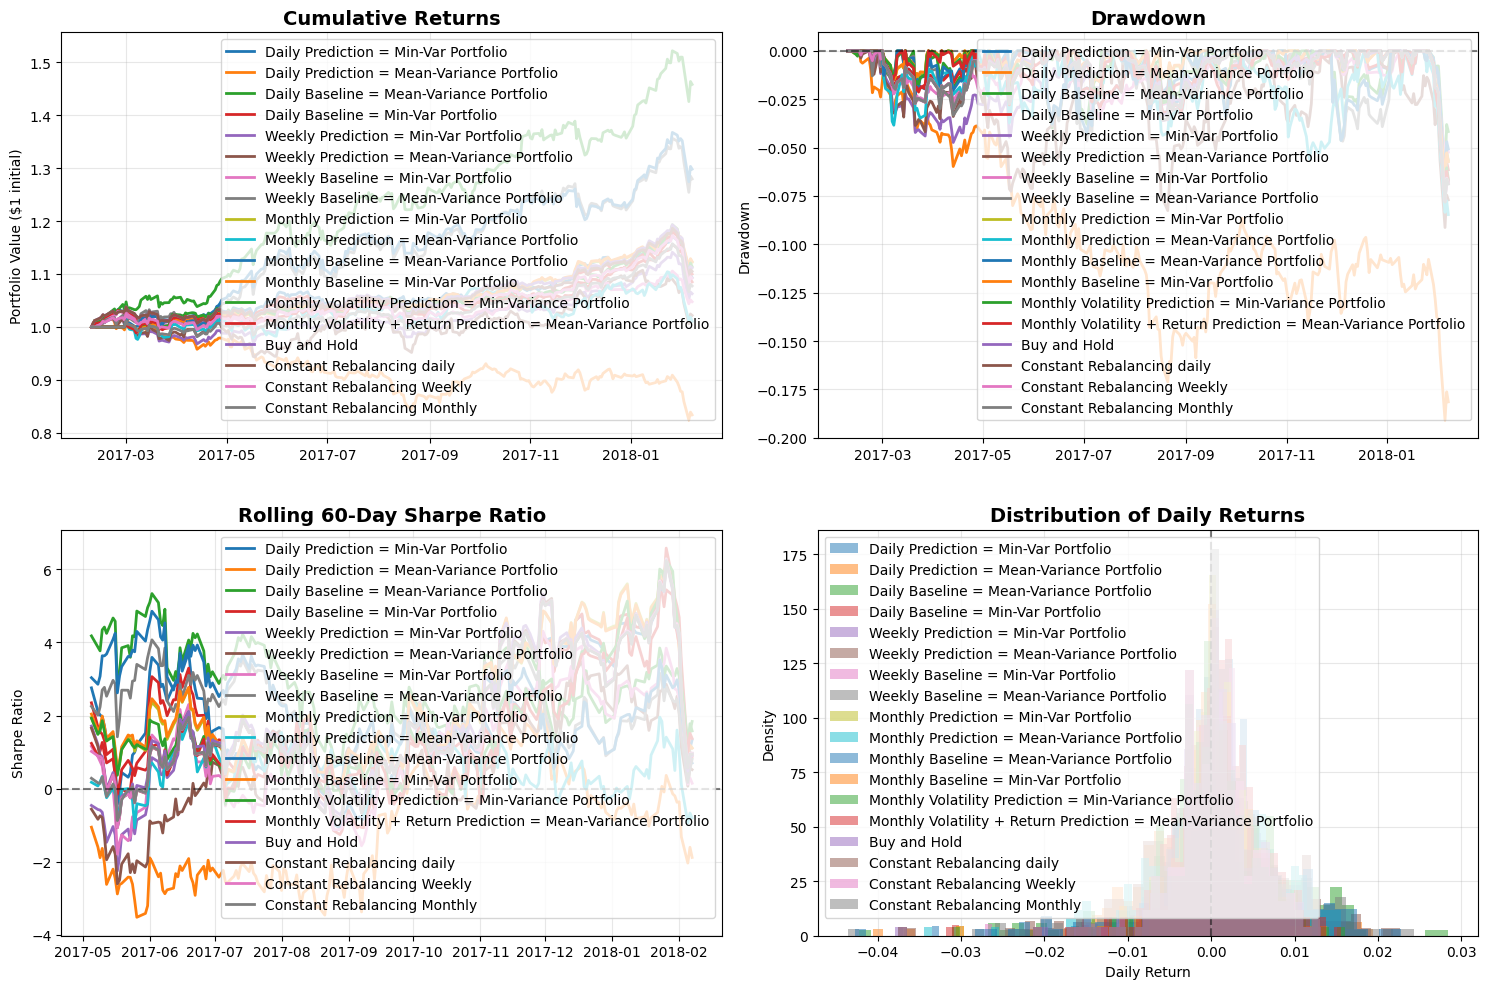

In [99]:
evaluator = PerformanceEvaluator(test_risk_free_rate)

comparison_df = evaluator.compare_strategies(results)
print("\nPerformance Comparison:")
print(comparison_df.to_string())

# ============================================================
# STEP 5: Visualize Results
# ============================================================
print("\n5. Generating Visualizations")
print("-" * 60)

fig = evaluator.plot_results(results, figsize=(15, 10))
plt.show()
